# Facial Emotion, Age Group, and Gender Prediction

## Deep Learning Course Project

**Project Partners:** Jahangir Amiri & Sadaf Aslam  
**Course:** Deep Learning  
**Instructor:** Sir Sajid Majeed  
**Program:** Post Graduate Diploma (PGD) in Data Science & AI  
**Institution:** NED University of Engineering & Technology

---

### Project Overview

This project develops a facial-analysis system with three prediction tasks:

- **Facial emotion classification** using a custom Convolutional Neural Network (CNN) trained on **FER2013**.
- **Age-group classification** using **MobileNetV2 transfer learning** trained on **UTKFace**.
- **Gender classification** using a second output head in the same MobileNetV2-based model.

The final models are integrated into a real-time OpenCV application for webcam-based inference.


## 1. Project Scope and Technical Approach

### Problem Definition

Given a face image, the system aims to estimate:

| Task | Dataset | Approach | Output |
|---|---|---|---|
| Emotion | FER2013 | Custom CNN | 7 emotion classes |
| Age group | UTKFace | MobileNetV2 + fine-tuning | 7 age groups |
| Gender | UTKFace | MobileNetV2 + fine-tuning | Binary classification |

### End-to-End Pipeline

```text
                    INPUT FACE
                        │
                 Haar Cascade
                  Face Detection
                        │
              ┌─────────┴─────────┐
              │                   │
         Emotion Branch      Age + Gender Branch
              │                   │
          48×48 Gray          128×128 RGB
              │                   │
          Custom CNN          MobileNetV2
              │              Transfer Learning
              │                   │
           Emotion        ┌───────┴────────┐
                          │                │
                      Age Group         Gender
```

FER2013 is grayscale and low-resolution; UTKFace provides RGB images suitable for transfer learning — the two branches reflect that difference.


## Notebook Contents

1. Project Scope and Technical Approach
2. Setup and Dataset Preparation
3. Emotion Classification (includes evaluation and error analysis)
4. Age and Gender Prediction
5. Fine-Tuning the Age/Gender Model (includes fine-tuning evaluation and prediction examples)
6. Model Export and Inference Readiness
7. Final Evaluation Summary
8. Limitations and Practical Considerations
9. Conclusion


## 2. Setup and Dataset Preparation


In [ ]:
# Check the TensorFlow version and available GPU.
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("TF version:", tf.__version__)

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF version: 2.20.0


In [ ]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.8 MB/s eta 0:00:00


In [ ]:
# Connect Kaggle API
import os
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

if os.environ["KAGGLE_USERNAME"] is None or os.environ["KAGGLE_KEY"] is None:
    raise ValueError("Please add KAGGLE_USERNAME and KAGGLE_KEY in Colab Secrets.")

print("Kaggle secrets loaded successfully.")

Kaggle secrets loaded successfully.


In [ ]:
# Download the FER2013 and UTKFace datasets from Kaggle.
!kaggle datasets download -d msambare/fer2013 -p /content/data/fer2013 --unzip
!kaggle datasets download -d jangedoo/utkface-new -p /content/data/utkface --unzip

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 164MB/s]

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:02<00:00, 121MB/s]



In [ ]:
# Inspect the FER2013 directory structure and class counts.
import os

fer_train = "/content/data/fer2013/train"
emotion_classes = sorted(os.listdir(fer_train))
print("Emotion classes:", emotion_classes)

for cls in emotion_classes:
    n = len(os.listdir(os.path.join(fer_train, cls)))
    print(f"  {cls}: {n} images")

Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  angry: 3995 images
  disgust: 436 images
  fear: 4097 images
  happy: 7215 images
  neutral: 4965 images
  sad: 4830 images
  surprise: 3171 images


### FER2013 Class Balance

A class-distribution chart is important because FER2013 contains substantially different numbers of images per emotion. This imbalance can affect training and is one reason class weights are introduced later.

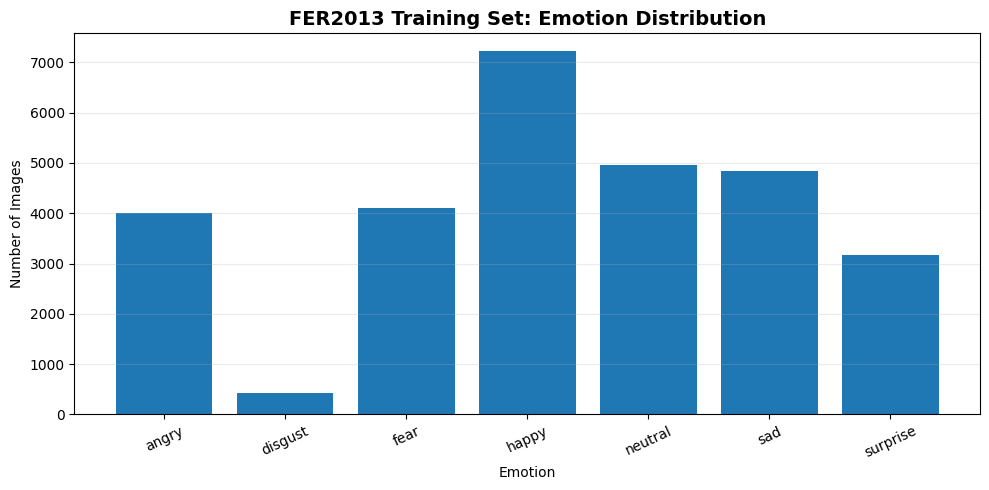

Largest class: happy - 7215
Smallest class: disgust - 436


In [ ]:
# Visualize the number of training images in each FER2013 emotion class.
import matplotlib.pyplot as plt
import numpy as np # Import numpy

fer_counts = [
    len(os.listdir(os.path.join(fer_train, cls)))
    for cls in emotion_classes
]

plt.figure(figsize=(10, 5))
bars = plt.bar(emotion_classes, fer_counts)
plt.title("FER2013 Training Set: Emotion Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print("Largest class:", emotion_classes[int(np.argmax(fer_counts))], "-", max(fer_counts))
print("Smallest class:", emotion_classes[int(np.argmin(fer_counts))], "-", min(fer_counts))

### Visual check of the FER2013 data

Before building the model, it is useful to look at a few actual images and confirm that the class labels match the facial expressions. The next cell displays random training examples from each emotion category.


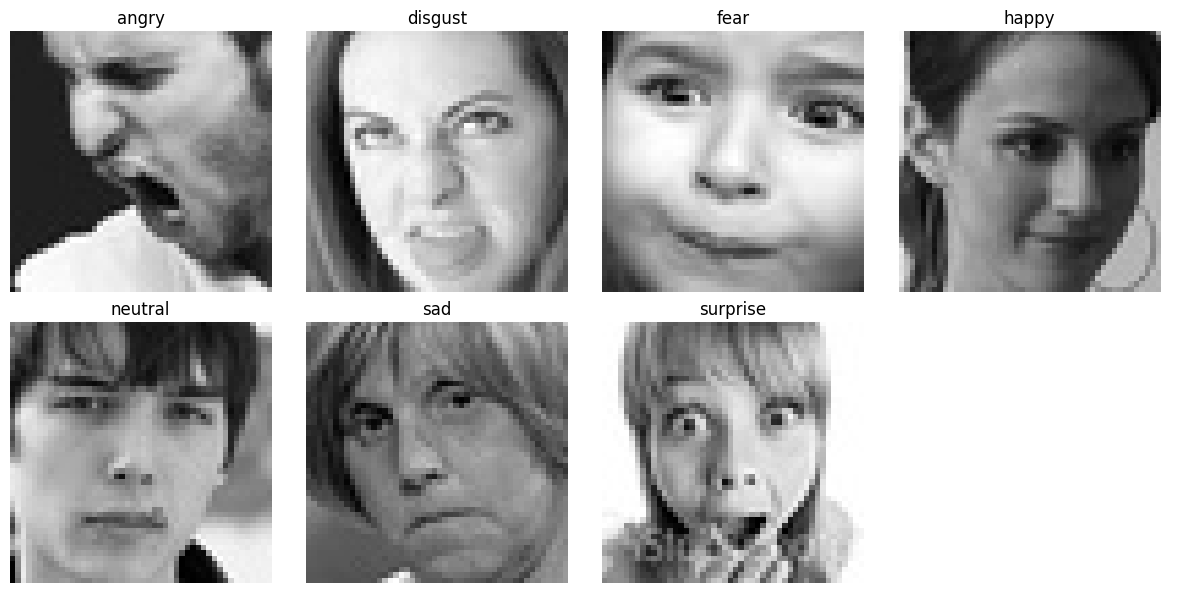

In [ ]:
import matplotlib.pyplot as plt
import random
from tensorflow.keras.utils import load_img

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for ax, emotion in zip(axes, emotion_classes):
    emotion_dir = os.path.join(fer_train, emotion)
    sample_file = random.choice(os.listdir(emotion_dir))
    image = load_img(os.path.join(emotion_dir, sample_file), color_mode="grayscale", target_size=(48, 48))
    ax.imshow(image, cmap="gray")
    ax.set_title(emotion)
    ax.axis("off")

# Hide the unused eighth subplot.
for ax in axes[len(emotion_classes):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# Inspect the UTKFace files and confirm the filename format.
utk_dir = "/content/data/utkface/UTKFace"
files_list = os.listdir(utk_dir)
print("Total UTKFace images:", len(files_list))
print("Sample filename:", files_list[0])
# Filename format: [age]_[gender]_[race]_[timestamp].jpg

Total UTKFace images: 23708
Sample filename: 8_1_4_20170103200403187.jpg.chip.jpg


### Visual check of the UTKFace data

UTKFace encodes age and gender in each filename. A few examples help verify both the images and the labels before creating the training pipeline.


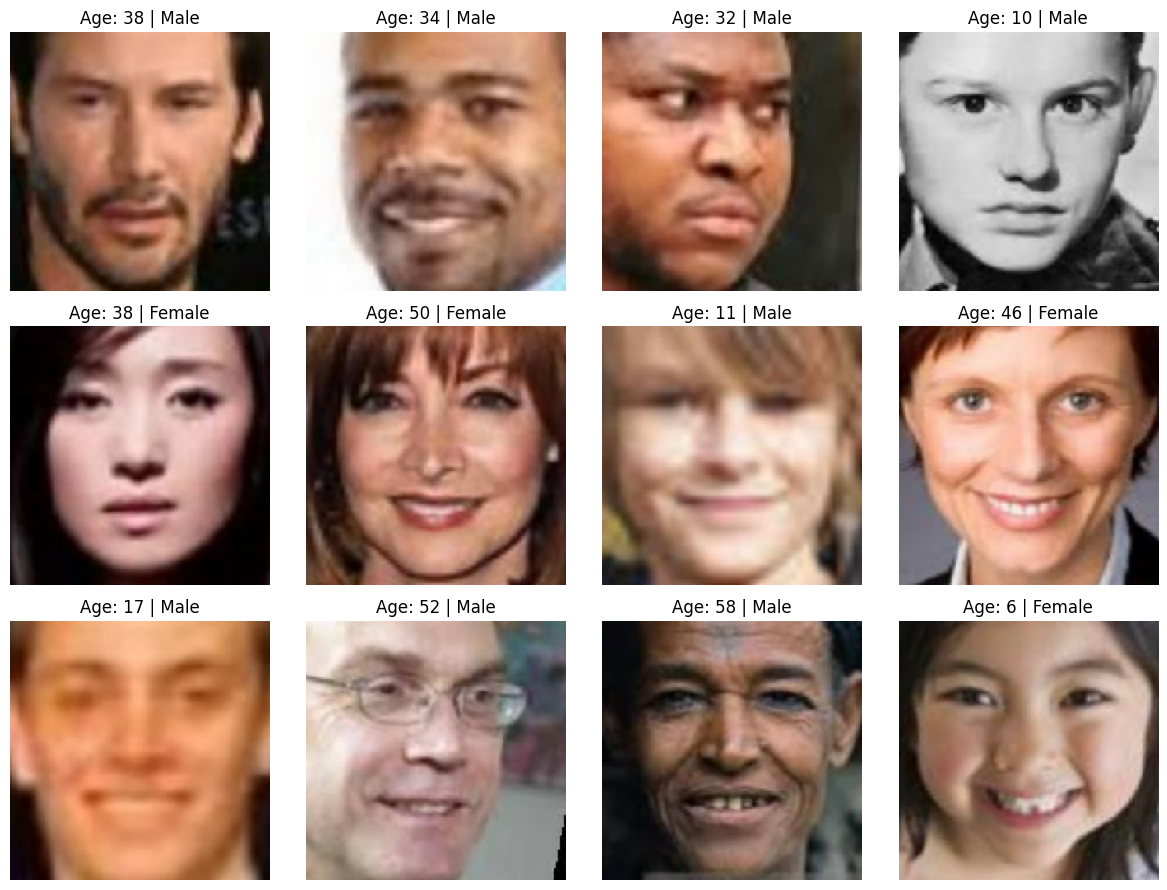

In [ ]:
import matplotlib.pyplot as plt
import random
from tensorflow.keras.utils import load_img

valid_files = [f for f in files_list if f.lower().endswith((".jpg", ".jpeg", ".png"))]
sample_files = random.sample(valid_files, min(12, len(valid_files)))

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.ravel()

for ax, fname in zip(axes, sample_files):
    try:
        age, gender, *_ = fname.split("_")
        gender_label = "Male" if int(gender) == 0 else "Female"
        image = load_img(os.path.join(utk_dir, fname), target_size=(128, 128))
        ax.imshow(image)
        ax.set_title(f"Age: {age} | {gender_label}")
    except (ValueError, IndexError):
        ax.set_title("Sample")
    ax.axis("off")

for ax in axes[len(sample_files):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


## 3. Emotion Classification


In [ ]:
# Create training and validation generators for FER2013.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 48
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    "/content/data/fer2013/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)
val_gen = val_datagen.flow_from_directory(
    "/content/data/fer2013/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

emotion_classes = list(train_gen.class_indices.keys())
print(emotion_classes)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:
# Calculate class weights so under-represented emotions have more influence during training.
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

labels = train_gen.classes
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


In [ ]:
# Build a CNN for seven-class facial emotion classification.
from tensorflow.keras import layers, models

def build_emotion_model(input_shape=(48, 48, 1), num_classes=7):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

emotion_model = build_emotion_model()
emotion_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
emotion_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,543 (615.40 KB)

 Trainable params: 156,903 (612.90 KB)

 Non-trainable params: 640 (2.50 KB)

### Training callbacks

Three callbacks are used during emotion training: **EarlyStopping** stops training when validation accuracy stops improving, **ModelCheckpoint** keeps the best validation checkpoint, and **ReduceLROnPlateau** lowers the learning rate when validation loss stops improving. Because `restore_best_weights=True`, the model is returned to its best validation state before the final `.keras` file is saved.


In [ ]:
# Train the emotion model with early stopping, checkpointing, and learning-rate reduction.
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True),
    ModelCheckpoint("emotion_model_best.keras", monitor="val_accuracy", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)
]

history_emotion = emotion_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=40,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 50s 86ms/step - accuracy: 0.1698 - loss: 1.9629 - val_accuracy: 0.1733 - val_loss: 1.9943 - learning_rate: 0.0010
Epoch 2/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.2298 - loss: 1.8668 - val_accuracy: 0.2739 - val_loss: 1.7852 - learning_rate: 0.0010
Epoch 3/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.2677 - loss: 1.7664 - val_accuracy: 0.3089 - val_loss: 1.7513 - learning_rate: 0.0010
Epoch 4/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.3166 - loss: 1.7017 - val_accuracy: 0.3371 - val_loss: 1.7040 - learning_rate: 0.0010
Epoch 5/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.3747 - loss: 1.6030 - val_accuracy: 0.3527 - val_loss: 1.6553 - learning_rate: 0.0010
Epoch 6/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.4050 - loss: 1.5406 - val_accuracy: 0.4785 - val_loss: 1.3764 - learning_rate: 0.0010
Epoch 7/40
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.4261 - l

In [ ]:
# Evaluate the emotion model and save the trained weights.
val_loss, val_acc = emotion_model.evaluate(val_gen)
print(f"Validation accuracy: {val_acc:.3f}")

emotion_model.save("emotion_model.keras")

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5945 - loss: 1.0514
Validation accuracy: 0.594


### Emotion Model — Training History

Training curves help us check whether the model learned progressively and whether the validation performance began to diverge from the training performance.

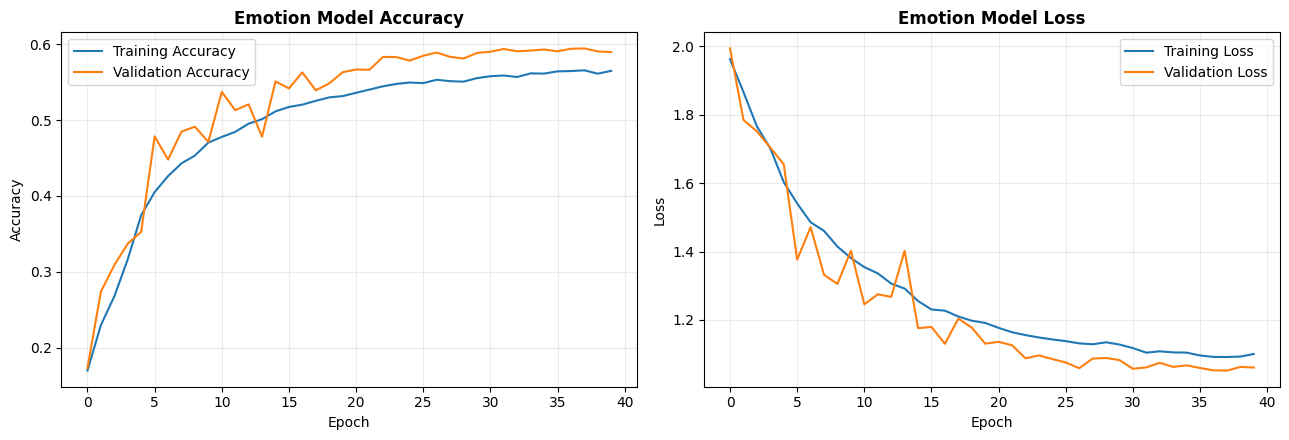

In [ ]:
# Plot emotion-model training and validation curves.
history_dict = history_emotion.history

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history_dict["accuracy"], label="Training Accuracy")
axes[0].plot(history_dict["val_accuracy"], label="Validation Accuracy")
axes[0].set_title("Emotion Model Accuracy", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(history_dict["loss"], label="Training Loss")
axes[1].plot(history_dict["val_loss"], label="Validation Loss")
axes[1].set_title("Emotion Model Loss", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


### Emotion Model — Confusion Matrix and Classification Report

Accuracy gives one overall number. A confusion matrix shows **which emotions the model confuses with one another**, while the classification report provides precision, recall, and F1-score for each class.

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


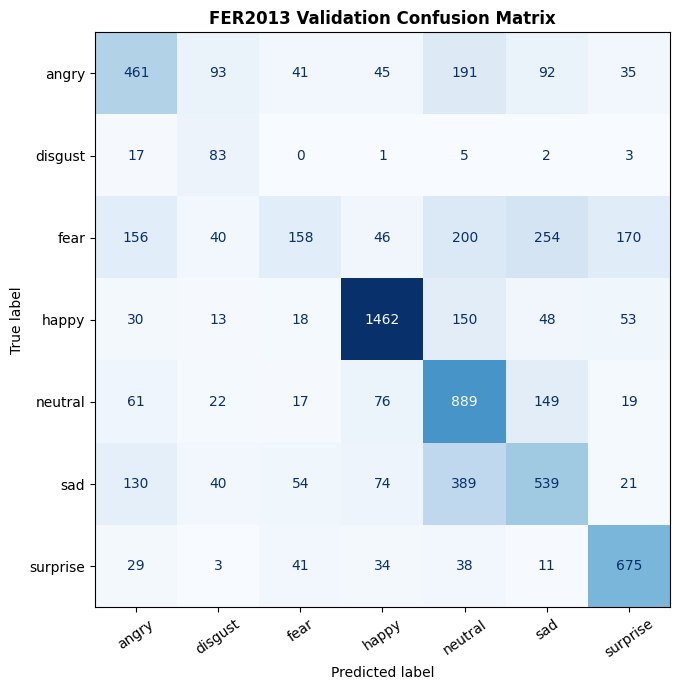

              precision    recall  f1-score   support

       angry      0.521     0.481     0.501       958
     disgust      0.282     0.748     0.410       111
        fear      0.480     0.154     0.234      1024
       happy      0.841     0.824     0.833      1774
     neutral      0.477     0.721     0.574      1233
         sad      0.492     0.432     0.460      1247
    surprise      0.692     0.812     0.747       831

    accuracy                          0.594      7178
   macro avg      0.541     0.596     0.537      7178
weighted avg      0.598     0.594     0.577      7178



In [ ]:
# Generate validation predictions for detailed emotion evaluation.
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

val_gen.reset()
emotion_probs = emotion_model.predict(val_gen, verbose=1)
emotion_pred = np.argmax(emotion_probs, axis=1)
emotion_true = val_gen.classes

cm = confusion_matrix(emotion_true, emotion_pred)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_classes)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=35, colorbar=False)
ax.set_title("FER2013 Validation Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.show()

print(classification_report(
    emotion_true,
    emotion_pred,
    target_names=emotion_classes,
    digits=3,
    zero_division=0
))


## 4. Age and Gender Prediction


In [ ]:
# Extract age and gender labels from the UTKFace filenames.
import os
import numpy as np

utk_dir = "/content/data/utkface/UTKFace"
image_paths, ages, genders = [], [], []

for fname in os.listdir(utk_dir):
    try:
        age, gender, *_ = fname.split("_")
        age = int(age)
        gender = int(gender)
        if 0 <= age <= 90:
            image_paths.append(os.path.join(utk_dir, fname))
            ages.append(age)
            genders.append(gender)
    except ValueError:
        continue

print("Total usable images:", len(image_paths))

Total usable images: 23621


In [ ]:
# Convert the exact ages into seven age groups for classification.
def age_to_bracket(age):
    if age < 13: return 0   # child
    elif age < 20: return 1 # teen
    elif age < 30: return 2 # 20-29
    elif age < 40: return 3 # 30-39
    elif age < 50: return 4 # 40-49
    elif age < 60: return 5 # 50-59
    else: return 6           # 60+

age_bracket_labels = ["0-12", "13-19", "20-29", "30-39", "40-49", "50-59", "60+"]
age_brackets = np.array([age_to_bracket(a) for a in ages])
genders = np.array(genders)

import collections
print("Bracket distribution:", collections.Counter(age_brackets))

Bracket distribution: Counter({np.int64(2): 7344, np.int64(3): 4537, np.int64(0): 3413, np.int64(6): 2603, np.int64(5): 2299, np.int64(4): 2245, np.int64(1): 1180})


### Check the age-group distribution

The age groups are not equally represented, so it is useful to inspect their distribution before training. This also helps explain why overall accuracy should be interpreted alongside the class frequencies.


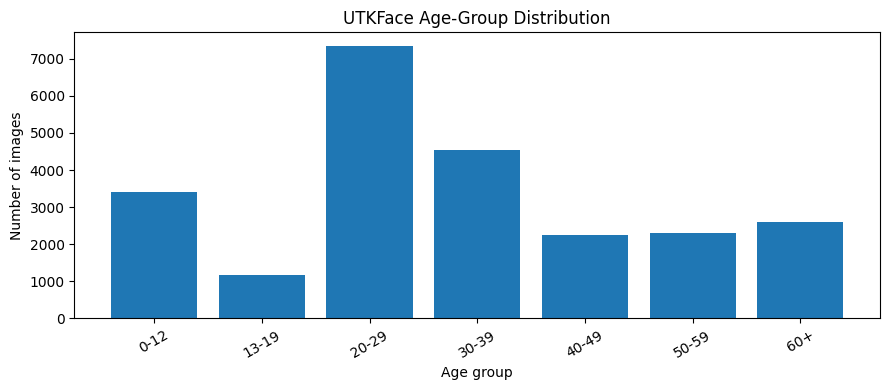

Gender distribution: {'Male': 12379, 'Female': 11242}


In [ ]:
import matplotlib.pyplot as plt

counts = np.bincount(age_brackets, minlength=len(age_bracket_labels))

plt.figure(figsize=(9, 4))
plt.bar(age_bracket_labels, counts)
plt.xlabel("Age group")
plt.ylabel("Number of images")
plt.title("UTKFace Age-Group Distribution")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print("Gender distribution:", {
    "Male": int(np.sum(genders == 0)),
    "Female": int(np.sum(genders == 1))
})


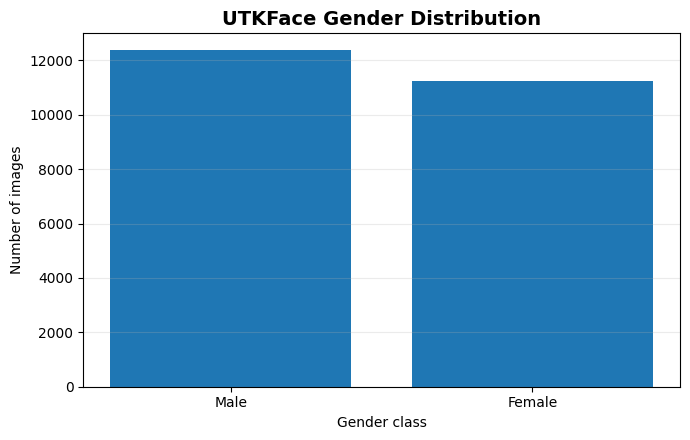

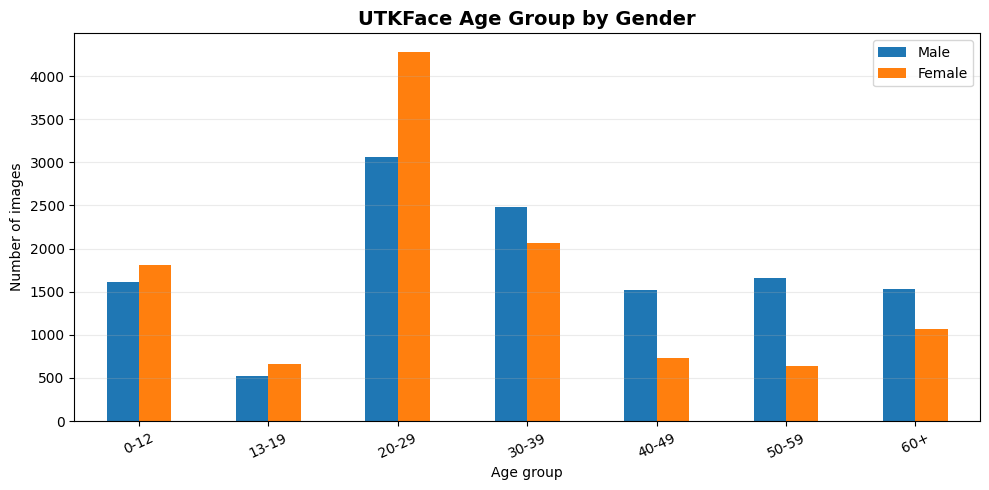

,Male,Female
0-12,1607,1806
13-19,521,659
20-29,3062,4282
30-39,2477,2060
40-49,1519,726
50-59,1659,640
60+,1534,1069


In [ ]:
# Visualize gender balance and the interaction between age group and gender.
gender_counts = [int(np.sum(genders == 0)), int(np.sum(genders == 1))]
gender_labels = ["Male", "Female"]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(gender_labels, gender_counts)
ax.set_title("UTKFace Gender Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Gender class")
ax.set_ylabel("Number of images")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Age-group × gender counts
import pandas as pd
cross_tab = pd.crosstab(
    pd.Series(age_brackets, name="Age Group"),
    pd.Series(genders, name="Gender")
)
cross_tab.index = age_bracket_labels
cross_tab.columns = ["Male", "Female"]

ax = cross_tab.plot(kind="bar", figsize=(10, 5))
ax.set_title("UTKFace Age Group by Gender", fontsize=14, fontweight="bold")
ax.set_xlabel("Age group")
ax.set_ylabel("Number of images")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

display(cross_tab)


In [ ]:
# Build a tf.data input pipeline for the age and gender model.
import tensorflow as tf
from sklearn.model_selection import train_test_split

IMG_SIZE = 128
BATCH_SIZE = 32

def load_and_preprocess(path, age_label, gender_label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    return img, {"age_output": age_label, "gender_output": gender_label}

paths_train, paths_val, age_train, age_val, gender_train, gender_val = \
    train_test_split(image_paths, age_brackets, genders, test_size=0.15, random_state=42, stratify=age_brackets)

def make_dataset(paths, ages, genders, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, ages, genders))
    if shuffle:
        ds = ds.shuffle(2000)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(paths_train, age_train, gender_train, shuffle=True)
val_ds = make_dataset(paths_val, age_val, gender_val)

In [ ]:
# Use MobileNetV2 as a pretrained feature extractor with two prediction heads.
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, Model

base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet")
base_model.trainable = False  # freeze for now — fast first pass

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)

age_output = layers.Dense(7, activation="softmax", name="age_output")(x)
gender_output = layers.Dense(1, activation="sigmoid", name="gender_output")(x)

age_gender_model = Model(inputs=inputs, outputs=[age_output, gender_output])

age_gender_model.compile(
    optimizer="adam",
    loss={"age_output": "sparse_categorical_crossentropy", "gender_output": "binary_crossentropy"},
    loss_weights={"age_output": 1.0, "gender_output": 0.5},
    metrics={"age_output": "accuracy", "gender_output": "accuracy"}
)
age_gender_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 4, 4,      │  2,257,984 │ input_layer_2[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_output (Dense)  │ (None, 7)         │      1,799 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_output       │ (None, 1)         │        257 │ dropout_4[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,587,976 (9.87 MB)

 Trainable params: 329,992 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Training callbacks

The initial age/gender model uses **EarlyStopping** and **ModelCheckpoint**. The checkpoint is a safety copy of the best validation epoch, while the final model saved after evaluation is also the best-weight version because `restore_best_weights=True`.


In [ ]:
# Train the multi-output model with the pretrained base frozen.
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor="val_age_output_accuracy", mode="max", patience=5, restore_best_weights=True),
    ModelCheckpoint("age_gender_model_best.keras", monitor="val_age_output_accuracy", mode="max", save_best_only=True)
]

history_ag = age_gender_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
628/628 ━━━━━━━━━━━━━━━━━━━━ 70s 81ms/step - age_output_accuracy: 0.4818 - age_output_loss: 1.3314 - gender_output_accuracy: 0.7826 - gender_output_loss: 0.4587 - loss: 1.5613 - val_age_output_accuracy: 0.5209 - val_age_output_loss: 1.1915 - val_gender_output_accuracy: 0.7926 - val_gender_output_loss: 0.4325 - val_loss: 1.4081
Epoch 2/25
628/628 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - age_output_accuracy: 0.5230 - age_output_loss: 1.2050 - gender_output_accuracy: 0.8167 - gender_output_loss: 0.3974 - loss: 1.4037 - val_age_output_accuracy: 0.5209 - val_age_output_loss: 1.1959 - val_gender_output_accuracy: 0.8378 - val_gender_output_loss: 0.3763 - val_loss: 1.3847
Epoch 3/25
628/628 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - age_output_accuracy: 0.5374 - age_output_loss: 1.1638 - gender_output_accuracy: 0.8298 - gender_output_loss: 0.3732 - loss: 1.3504 - val_age_output_accuracy: 0.5291 - val_age_output_loss: 1.1726 - val_gender_output_accuracy: 0.8313 - val_gender_output_loss: 0.3674

### Initial MobileNetV2 Training Curves

The first stage keeps the pretrained MobileNetV2 feature extractor frozen. This establishes a baseline before fine-tuning the final portion of the backbone.

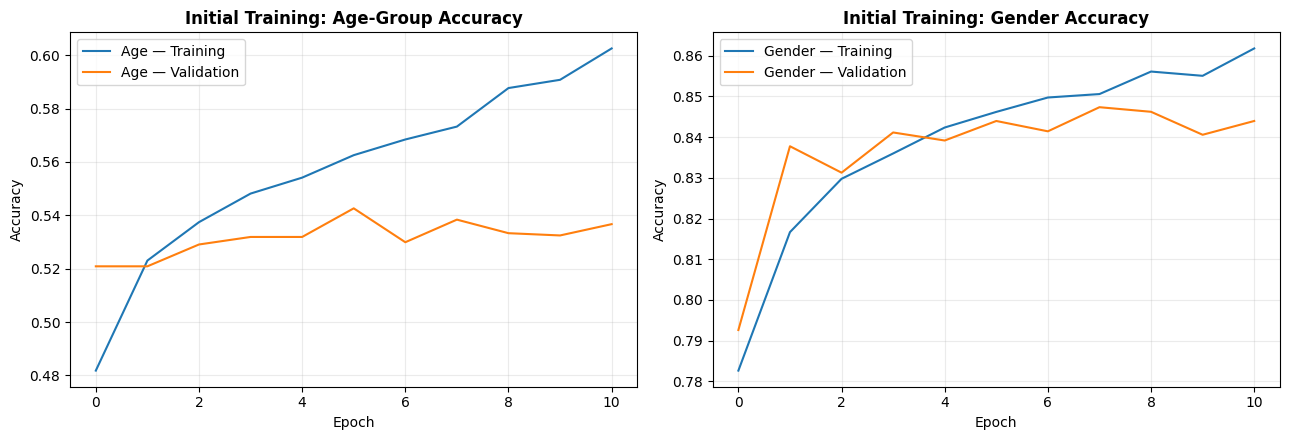

In [ ]:
# Plot age and gender validation performance during the frozen-backbone stage.
h = history_ag.history

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(h["age_output_accuracy"], label="Age — Training")
axes[0].plot(h["val_age_output_accuracy"], label="Age — Validation")
axes[0].set_title("Initial Training: Age-Group Accuracy", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(h["gender_output_accuracy"], label="Gender — Training")
axes[1].plot(h["val_gender_output_accuracy"], label="Gender — Validation")
axes[1].set_title("Initial Training: Gender Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [ ]:
# Evaluate the initial transfer-learning model and save it for later use.
results = age_gender_model.evaluate(val_ds, return_dict=True)
print(results)

age_gender_model.save("age_gender_model.keras")


111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - age_output_accuracy: 0.5770 - age_output_loss: 1.1086 - gender_output_accuracy: 0.8651 - gender_output_loss: 0.3296 - loss: 1.2742
{'age_output_accuracy': 0.5770316123962402, 'age_output_loss': 1.1086138486862183, 'gender_output_accuracy': 0.8651241660118103, 'gender_output_loss': 0.3295918405056, 'loss': 1.2741600275039673}


## 5. Fine-Tuning the Age/Gender Model


In [ ]:
# Unfreeze the last part of MobileNetV2 and fine-tune it with a small learning rate.
base_model.trainable = True

# Keep early layers frozen (generic features), only unfreeze the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

from tensorflow.keras.optimizers import Adam

age_gender_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss={"age_output": "sparse_categorical_crossentropy", "gender_output": "binary_crossentropy"},
    loss_weights={"age_output": 1.0, "gender_output": 0.5},
    metrics={"age_output": "accuracy", "gender_output": "accuracy"}
)

age_gender_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_1… │ (None, 4, 4,      │  2,257,984 │ input_layer_2[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_output (Dense)  │ (None, 7)         │      1,799 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_output       │ (None, 1)         │        257 │ dropout_4[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,587,976 (9.87 MB)

 Trainable params: 1,856,392 (7.08 MB)

 Non-trainable params: 731,584 (2.79 MB)

### Fine-tuning callbacks

The fine-tuning stage again uses **EarlyStopping** and **ModelCheckpoint**. The best validation-age-accuracy weights are restored before the final fine-tuned model is saved.


In [ ]:
# Fine-tune the model and keep the version with the best validation age accuracy.
callbacks_ft = [
    EarlyStopping(monitor="val_age_output_accuracy", mode="max", patience=6, restore_best_weights=True),
    ModelCheckpoint("age_gender_model_finetuned.keras", monitor="val_age_output_accuracy",
                     mode="max", save_best_only=True)
]

history_ft = age_gender_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_ft
)

Epoch 1/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 51s 54ms/step - age_output_accuracy: 0.6319 - age_output_loss: 0.8809 - gender_output_accuracy: 0.8798 - gender_output_loss: 0.2737 - loss: 1.0172 - val_age_output_accuracy: 0.5742 - val_age_output_loss: 1.1073 - val_gender_output_accuracy: 0.8671 - val_gender_output_loss: 0.3247 - val_loss: 1.2704
Epoch 2/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - age_output_accuracy: 0.6518 - age_output_loss: 0.8414 - gender_output_accuracy: 0.8874 - gender_output_loss: 0.2631 - loss: 0.9724 - val_age_output_accuracy: 0.5742 - val_age_output_loss: 1.1151 - val_gender_output_accuracy: 0.8677 - val_gender_output_loss: 0.3232 - val_loss: 1.2777
Epoch 3/20
628/628 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - age_output_accuracy: 0.6596 - age_output_loss: 0.8183 - gender_output_accuracy: 0.8900 - gender_output_loss: 0.2544 - loss: 0.9454 - val_age_output_accuracy: 0.5722 - val_age_output_loss: 1.1184 - val_gender_output_accuracy: 0.8665 - val_gender_output_loss: 0.3238

In [ ]:
# Evaluate and save the fine-tuned model.
results_ft = age_gender_model.evaluate(val_ds, return_dict=True)
print(results_ft)

age_gender_model.save("age_gender_model_finetuned.keras")


111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - age_output_accuracy: 0.5807 - age_output_loss: 1.1361 - gender_output_accuracy: 0.8719 - gender_output_loss: 0.3313 - loss: 1.3029
{'age_output_accuracy': 0.5806998014450073, 'age_output_loss': 1.1361221075057983, 'gender_output_accuracy': 0.8718961477279663, 'gender_output_loss': 0.33132925629615784, 'loss': 1.3028866052627563}


### Fine-Tuning Curves

Only the final portion of MobileNetV2 is unfrozen and trained with a small learning rate. This allows the pretrained representation to adapt to the UTKFace task while reducing the risk of destroying useful pretrained features.

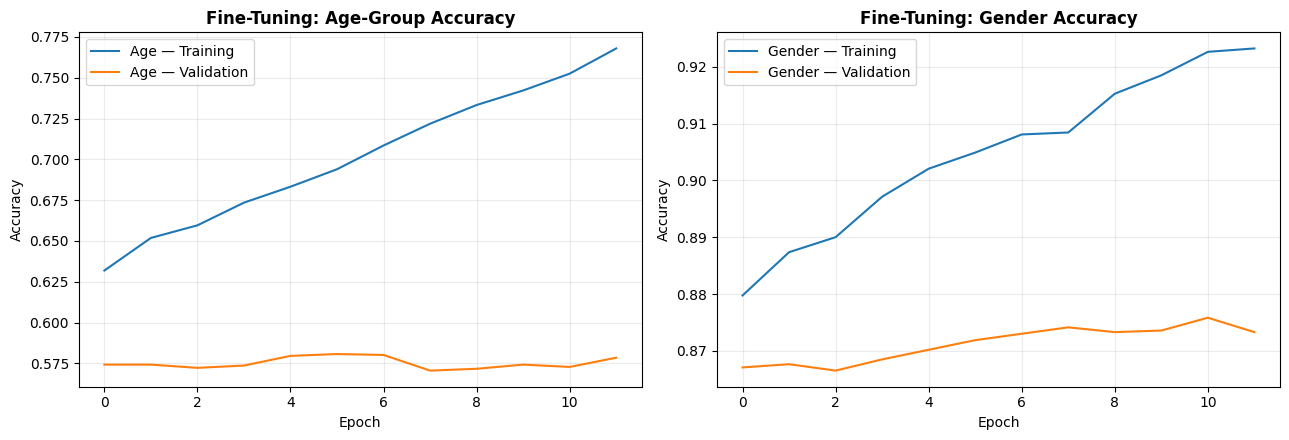

In [ ]:
# Plot fine-tuning performance for age and gender.
hft = history_ft.history

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(hft["age_output_accuracy"], label="Age — Training")
axes[0].plot(hft["val_age_output_accuracy"], label="Age — Validation")
axes[0].set_title("Fine-Tuning: Age-Group Accuracy", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(hft["gender_output_accuracy"], label="Gender — Training")
axes[1].plot(hft["val_gender_output_accuracy"], label="Gender — Validation")
axes[1].set_title("Fine-Tuning: Gender Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


### Before vs After Fine-Tuning

This comparison makes the purpose of fine-tuning explicit rather than leaving it as another training block.

,Stage,Age accuracy,Gender accuracy
0,Initial transfer learning,0.577,0.865
1,Fine-tuned,0.581,0.872


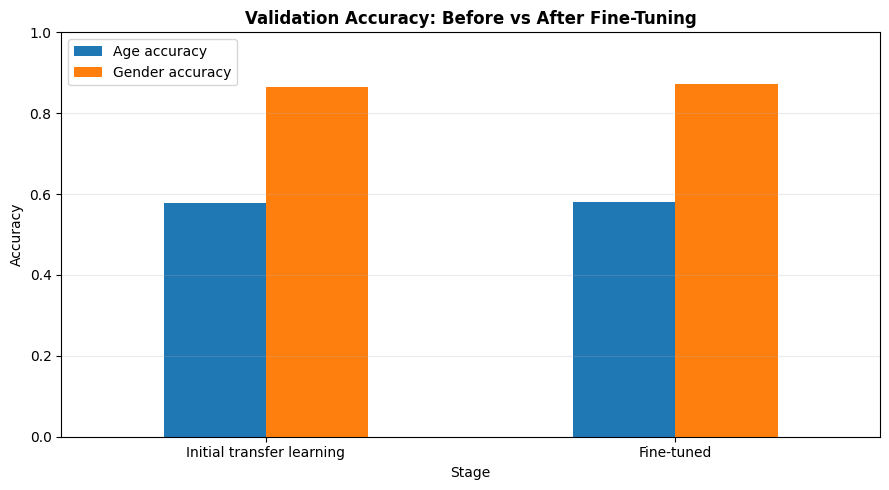

In [ ]:
# Compare the final validation accuracy before and after fine-tuning.
initial_age_acc = float(results.get("age_output_accuracy", np.nan))
initial_gender_acc = float(results.get("gender_output_accuracy", np.nan))
final_age_acc = float(results_ft.get("age_output_accuracy", np.nan))
final_gender_acc = float(results_ft.get("gender_output_accuracy", np.nan))

comparison = pd.DataFrame({
    "Stage": ["Initial transfer learning", "Fine-tuned"],
    "Age accuracy": [initial_age_acc, final_age_acc],
    "Gender accuracy": [initial_gender_acc, final_gender_acc]
})

display(comparison.style.format({"Age accuracy": "{:.3f}", "Gender accuracy": "{:.3f}"}))

ax = comparison.set_index("Stage").plot(kind="bar", figsize=(9, 5))
ax.set_title("Validation Accuracy: Before vs After Fine-Tuning", fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


### Example Predictions

A small set of validation examples provides a qualitative check of how the trained age/gender model behaves on real images. The labels below are **model predictions**, not identity claims.

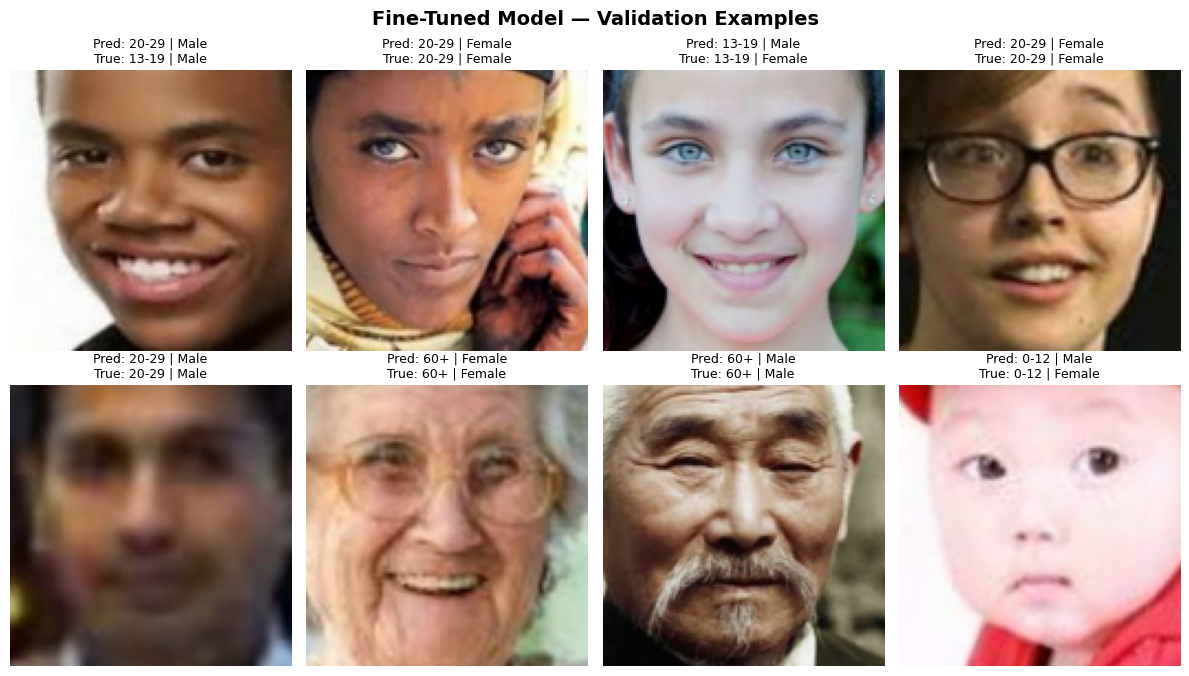

In [ ]:
# Show a small sample of validation predictions from the fine-tuned model.
sample_count = 8
sample_indices = np.random.default_rng(42).choice(len(paths_val), size=min(sample_count, len(paths_val)), replace=False)

sample_paths = [paths_val[i] for i in sample_indices]
sample_images = []

for path in sample_paths:
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE]) / 255.0
    sample_images.append(img.numpy())

sample_batch = np.stack(sample_images)
age_probs, gender_probs = age_gender_model.predict(sample_batch, verbose=0)
pred_age = np.argmax(age_probs, axis=1)
pred_gender = (gender_probs.ravel() >= 0.5).astype(int)

fig, axes = plt.subplots(2, 4, figsize=(12, 7))
axes = axes.ravel()

for j, (ax, path, idx) in enumerate(zip(axes, sample_paths, sample_indices)):
    ax.imshow(sample_images[j])
    true_age = age_bracket_labels[int(age_val[idx])]
    true_gender = "Male" if int(gender_val[idx]) == 0 else "Female"
    pred_gender_label = "Male" if pred_gender[j] == 0 else "Female"
    ax.set_title(
        f"Pred: {age_bracket_labels[pred_age[j]]} | {pred_gender_label}\n"
        f"True: {true_age} | {true_gender}",
        fontsize=9
    )
    ax.axis("off")

for ax in axes[len(sample_paths):]:
    ax.axis("off")

plt.suptitle("Fine-Tuned Model — Validation Examples", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Model Export and Inference Readiness


### Model Export


In [ ]:
from google.colab import drive
import os, shutil

drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/FER_UTK_Project"
os.makedirs(PROJECT_DIR, exist_ok=True)

# These are the three models needed for later inference or deployment.
files_to_save = [
    "emotion_model.keras",
    "age_gender_model.keras",
    "age_gender_model_finetuned.keras"
]

for file in files_to_save:
    if os.path.exists(file):
        shutil.copy2(file, PROJECT_DIR)
        print("Saved:", file)

print("\n✅ All available trained models are safely saved to Google Drive.")

Mounted at /content/drive
Saved: emotion_model.keras
Saved: age_gender_model.keras
Saved: age_gender_model_finetuned.keras

✅ All available trained models are safely saved to Google Drive.


## 7. Final Evaluation Summary

The final results below are generated from the actual evaluation variables in this notebook. This avoids manually copying numbers and reduces the risk of reporting inconsistent metrics.

In [ ]:
# Building a concise final results table from the actual evaluation results.
final_results = pd.DataFrame({
    "Task": ["Emotion classification", "Age-group classification", "Gender classification"],
    "Dataset": ["FER2013", "UTKFace", "UTKFace"],
    "Model": ["Custom CNN", "MobileNetV2 + fine-tuning", "MobileNetV2 + fine-tuning"],
    "Validation accuracy": [
        float(val_acc),
        final_age_acc,
        final_gender_acc
    ]
})

display(final_results.style.format({"Validation accuracy": "{:.3f}"}))


,Task,Dataset,Model,Validation accuracy
0,Emotion classification,FER2013,Custom CNN,0.594
1,Age-group classification,UTKFace,MobileNetV2 + fine-tuning,0.581
2,Gender classification,UTKFace,MobileNetV2 + fine-tuning,0.872


## 8. Limitations and Practical Considerations

- FER2013 is a challenging dataset with class imbalance and relatively small grayscale images.
- Age is reported as a **group**, not an exact age.
- Predictions are model estimates and can be affected by lighting, pose, image quality, occlusion, and dataset bias.
- Haar Cascade provides face detection but is not a modern face-detection/recognition system.
- Gender output represents the model's learned binary class prediction and should not be interpreted as a definitive statement about a person's identity.
- The system is intended as an educational Deep Learning project and demonstration, not as a high-stakes biometric system.


## 9. Conclusion

This project demonstrates an end-to-end facial-analysis workflow covering dataset exploration, preprocessing, CNN development, transfer learning, multi-output prediction, fine-tuning, quantitative evaluation, qualitative inspection, model export, and real-time inference.

The final system combines a custom CNN for emotion recognition with a MobileNetV2-based multi-task model for age-group and gender prediction. The trained models can then be connected to the OpenCV webcam application for practical demonstration.
